# 📊 Análisis Estratégico del Mercado Salarial en Tech, BI & AI

Evaluación de la Compensación, Retención de Talento y Modelos de Trabajo en la Industria Digital

### 🏢 Introducción y Contexto de Negocio

En la era del Big Data y la transformación digital, la atracción y retención de talento especializado en Business Intelligence, Ciencia de Datos e Inteligencia Artificial se ha convertido en un pilar crítico para la ventaja competitiva de las organizaciones. No obstante, las empresas se enfrentan a un mercado altamente volátil, caracterizado por la presión salarial global, la adopción masiva de modelos de trabajo flexibles y la evolución acelerada de roles técnicos hacia puestos de impacto estratégico.

#### Objetivo del Análisis

El propósito de este proyecto es examinar la estructura retributiva del sector tecnológico para proporcionar materia prima de decisión a líderes de People Analytics, Directores Financieros (CFOs) y Ejecutivos de Operaciones. A través del análisis de datos salariales, se busca responder a las siguientes preguntas clave de gestión:

Eficiencia en la Escala de Carrera: ¿Cómo escala la compensación a lo largo de la curva de experiencia y qué implicaciones tiene para el diseño de planes de retención interna?

Impacto Económico del Modelo de Trabajo: ¿Representa el trabajo remoto un factor de descuento salarial o se consolida como una estrategia efectiva para la captación de talento global?

Puestos de Alto Impacto (Core vs. Soporte): ¿Qué especializaciones y posiciones de liderazgo concentran los mayores presupuestos dentro de la arquitectura de datos corporativa?

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("jobs_in_data.csv")

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9355 entries, 0 to 9354
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           9355 non-null   int64 
 1   job_title           9355 non-null   object
 2   job_category        9355 non-null   object
 3   salary_currency     9355 non-null   object
 4   salary              9355 non-null   int64 
 5   salary_in_usd       9355 non-null   int64 
 6   employee_residence  9355 non-null   object
 7   experience_level    9355 non-null   object
 8   employment_type     9355 non-null   object
 9   work_setting        9355 non-null   object
 10  company_location    9355 non-null   object
 11  company_size        9355 non-null   object
dtypes: int64(3), object(9)
memory usage: 548.2+ KB
None


In [6]:
display(df.head())

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M


In [7]:
import numpy as np

# 1. Eliminar duplicados si los hubiera
df = df.drop_duplicates().copy()

In [8]:
# 2. Mapear niveles de experiencia a nombres más claros
exp_map = {
    'EN': 'Entry-level',
    'MI': 'Mid-level',
    'SE': 'Senior',
    'EX': 'Executive'
}

df['experience_level'] = df['experience_level'].replace(exp_map)

In [9]:
# 3. Mapear tamaños de empresa
size_map = {
    'S': 'Small',
    'M': 'Medium',
    'L': 'Large'
}

df['company_size'] = df['company_size'].replace(size_map)

In [10]:
# 4. Resumen estadístico salarial en USD
print(df[['salary_in_usd']].describe().T)

                count           mean           std      min      25%  \
salary_in_usd  5341.0  146258.409099  66594.117529  15000.0  98506.0   

                    50%       75%       max  
salary_in_usd  140000.0  186000.0  450000.0  


In [17]:
%pip install seaborn

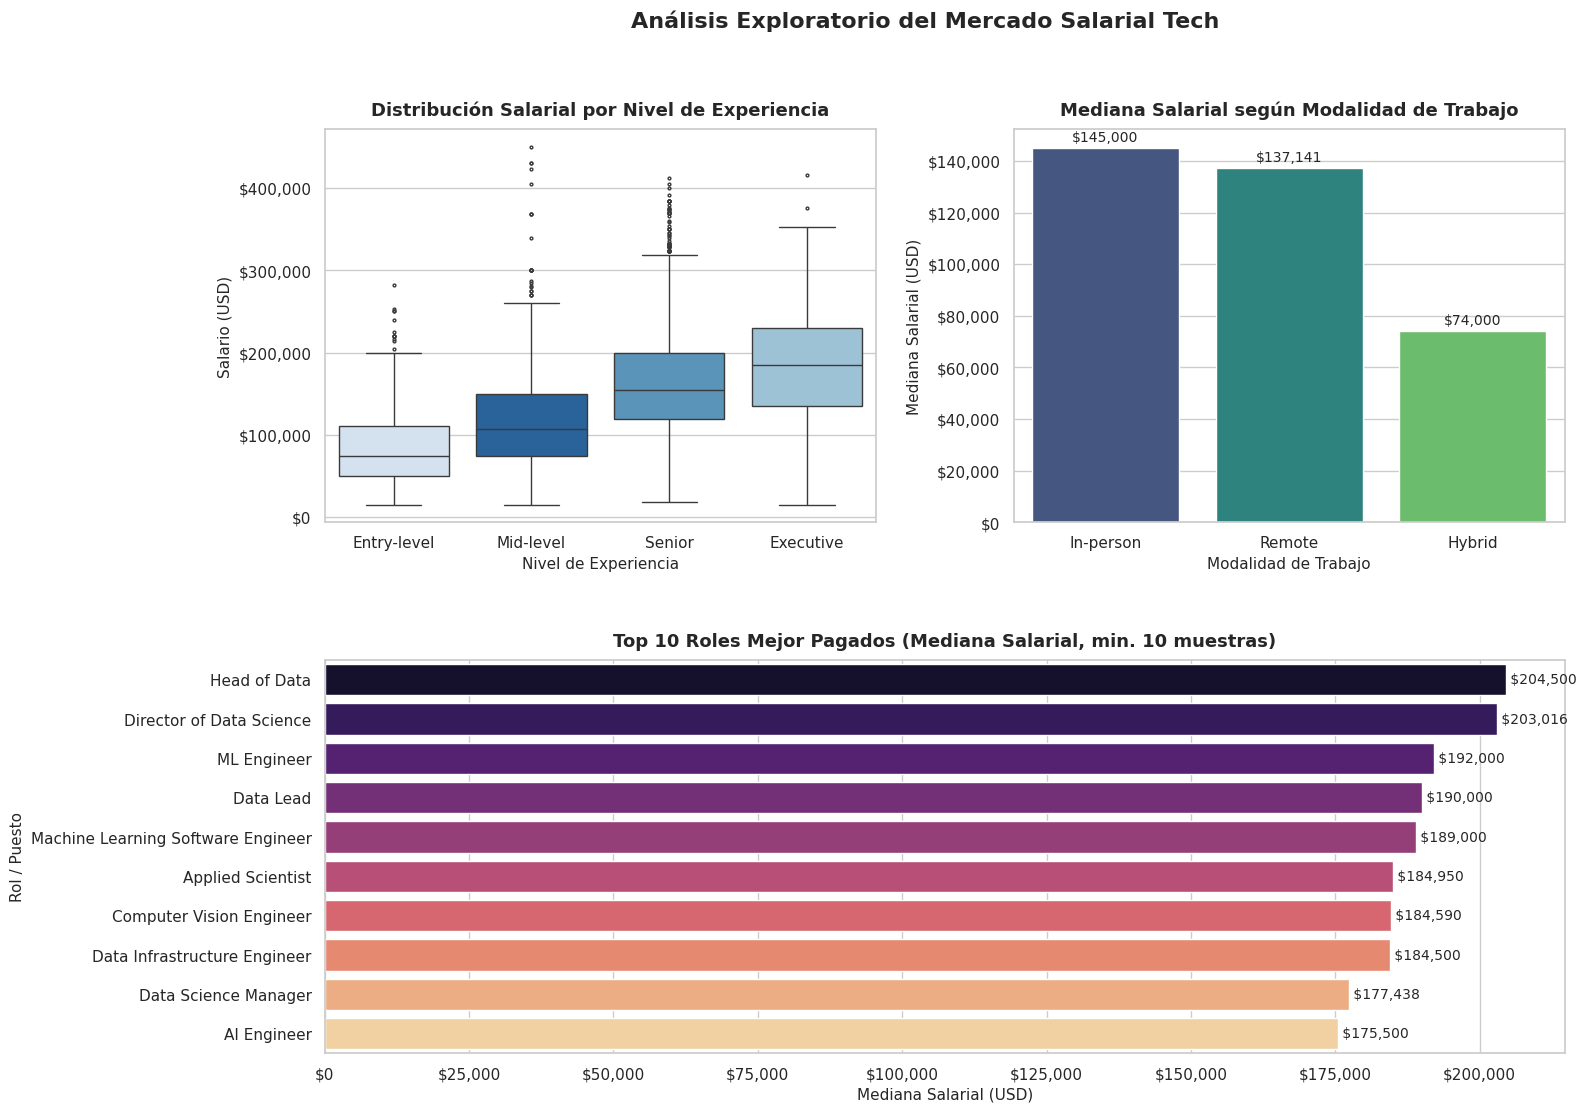

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuración de estilo global
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Crear figura con 3 subplots (2 arriba, 1 abajo)
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# ---------------------------------------------------------
# 1. Distribución Salarial por Nivel de Experiencia (Boxplot)
# ---------------------------------------------------------
order_exp = ["Entry-level", "Mid-level", "Senior", "Executive"]
present_exp = [e for e in order_exp if e in df["experience_level"].unique()]

sns.boxplot(
    data=df,
    x="experience_level",
    y="salary_in_usd",
    hue="experience_level",
    order=present_exp,
    palette="Blues_r",
    legend=False,
    ax=ax1,
    fliersize=2,
)

ax1.set_title(
    "Distribución Salarial por Nivel de Experiencia",
    fontsize=13,
    weight="bold",
    pad=10,
)
ax1.set_xlabel("Nivel de Experiencia", fontsize=11)
ax1.set_ylabel("Salario (USD)", fontsize=11)
ax1.yaxis.set_major_formatter("${x:,.0f}")

# ---------------------------------------------------------
# 2. Salario Mediano por Modalidad de Trabajo (Barplot)
# ---------------------------------------------------------
work_stats = (
    df.groupby("work_setting")["salary_in_usd"].median().reset_index()
)
work_stats = work_stats.sort_values(by="salary_in_usd", ascending=False)

bars = sns.barplot(
    data=work_stats,
    x="work_setting",
    y="salary_in_usd",
    hue="work_setting",
    palette="viridis",
    legend=False,
    ax=ax2,
)

ax2.set_title(
    "Mediana Salarial según Modalidad de Trabajo",
    fontsize=13,
    weight="bold",
    pad=10,
)
ax2.set_xlabel("Modalidad de Trabajo", fontsize=11)
ax2.set_ylabel("Mediana Salarial (USD)", fontsize=11)
ax2.yaxis.set_major_formatter("${x:,.0f}")

for bar in bars.patches:
    ax2.annotate(
        f"${bar.get_height():,.0f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )

# ---------------------------------------------------------
# 3. Top 10 Roles Mejor Pagados (Mediana Salarial)
# ---------------------------------------------------------
top_roles = (
    df.groupby("job_title")
    .filter(lambda x: len(x) >= 10)
    .groupby("job_title")["salary_in_usd"]
    .median()
    .nlargest(10)
    .reset_index()
)

sns.barplot(
    data=top_roles,
    x="salary_in_usd",
    y="job_title",
    hue="job_title",
    palette="magma",
    legend=False,
    ax=ax3,
)

ax3.set_title(
    "Top 10 Roles Mejor Pagados (Mediana Salarial, min. 10 muestras)",
    fontsize=13,
    weight="bold",
    pad=10,
)
ax3.set_xlabel("Mediana Salarial (USD)", fontsize=11)
ax3.set_ylabel("Rol / Puesto", fontsize=11)
ax3.xaxis.set_major_formatter("${x:,.0f}")

for bar in ax3.patches:
    ax3.annotate(
        f" ${bar.get_width():,.0f}",
        (bar.get_width(), bar.get_y() + bar.get_height() / 2),
        ha="left",
        va="center",
        fontsize=10,
    )

plt.suptitle(
    "Análisis Exploratorio del Mercado Salarial Tech",
    fontsize=16,
    weight="bold",
    y=0.98,
)
plt.show()

### Conclusiones

El análisis exploratorio del mercado laboral en datos e inteligencia artificial revela dinámicas clave sobre la estructura salarial, la retención de talento y los modelos de trabajo:

* Incentivos a la Profesionalización y Curva de Experiencia: Existe un salto cuantitativo sustancial en la compensación al pasar de roles Entry-level a niveles Senior y Executive. Desde una perspectiva de HR Analytics y gestión del talento, esto demuestra que el mercado premia drásticamente el impacto estratégico y la capacidad de resolución de problemas complejos por encima de la ejecución operativa inicial. Diseñar planes de carrera internos claros es fundamental para reducir la fuga de talento en etapas intermedias.
  
* Paradigma de la Modalidad de Trabajo (Presencial vs. Remoto vs. Híbrido): Contrario a la creencia de que el trabajo remoto deprecia la compensación, los salarios en esquemas Remote se mantienen altamente competitivos y a la par de las ofertas In-person. Sin embargo, el esquema Hybrid registra los niveles salariales más bajos del dataset, lo que sugiere que las empresas utilizan el trabajo presencial o 100% remoto como un incentivo económico clave para atraer talento altamente especializado a nivel global.

* Valoración Estratégica del Liderazgo y Especialización en IA: El mercado asigna las valoraciones más altas a dos perfiles específicos: la gestión ejecutiva (Head of Data, Director of Data Science) y los roles técnicos especializados en desarrollo de infraestructura e Inteligencia Artificial (ML Engineers, Applied Scientists). Para las organizaciones, esto implica que las inversiones en BI y Big Data ya no son vistas como centros de costos operativos, sino como motores de ventaja competitiva directa.